In [3]:
from datasets import load_dataset

# First run downloads ~80MB and caches it
# Every run after that loads from cache instantly
dataset = load_dataset("imdb")

print(dataset)





README.md: 0.00B [00:00, ?B/s]

C:\Users\admin\projects\bert-sentiment\venv\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\admin\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
sample = dataset['train'][0]

print(f"Label : {sample['label']}  (0=negative, 1=positive)")
print(f"Text  :\n{sample['text']}")

Label : 0  (0=negative, 1=positive)
Text  :
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex an

In [5]:
from collections import Counter

train_labels = [ex['label'] for ex in dataset['train']]
test_labels  = [ex['label'] for ex in dataset['test']]

print("Train label counts:", Counter(train_labels))
print("Test  label counts:", Counter(test_labels))


Train label counts: Counter({0: 12500, 1: 12500})
Test  label counts: Counter({0: 12500, 1: 12500})


In [6]:
positives = [ex for ex in dataset['train'] if ex['label'] == 1][:3]
negatives = [ex for ex in dataset['train'] if ex['label'] == 0][:3]

print("=" * 60)
print("POSITIVE REVIEWS")
print("=" * 60)
for i, ex in enumerate(positives):
    print(f"\n[{i+1}] {ex['text'][:400]}")
    print("-" * 40)

print("\n" + "=" * 60)
print("NEGATIVE REVIEWS")
print("=" * 60)
for i, ex in enumerate(negatives):
    print(f"\n[{i+1}] {ex['text'][:400]}")
    print("-" * 40)

POSITIVE REVIEWS

[1] Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-
----------------------------------------

[2] Zentropa is the most original movie I've seen in years. If you like unique thrillers that are influenced by film noir, then this is just the right cure for all of those Hollywood summer blockbusters clogging the theaters these days. Von Trier's follow-ups like Breaking the Waves have gotten more acclaim, but this is really his best work. It is flashy without being distracting and offers the perfec
----------------------------------------

[3] Lars Von Trier is never backward in trying out new techniques. Some of them are very

Shortest review : 10 words
Median length   : 174 words
90th percentile : 458 words
95th percentile : 598 words
Longest review  : 2470 words


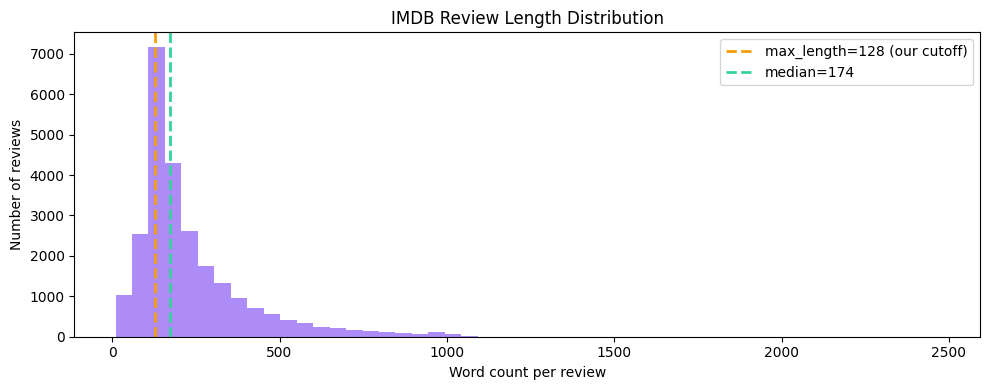

✓ Saved to data/length_distribution.png


In [7]:
import matplotlib.pyplot as plt

# Count word lengths for all 25,000 training reviews
lengths = [len(ex['text'].split()) for ex in dataset['train']]

lengths_sorted = sorted(lengths)
n = len(lengths_sorted)

print(f"Shortest review : {lengths_sorted[0]} words")
print(f"Median length   : {lengths_sorted[n//2]} words")
print(f"90th percentile : {lengths_sorted[int(n*0.9)]} words")
print(f"95th percentile : {lengths_sorted[int(n*0.95)]} words")
print(f"Longest review  : {lengths_sorted[-1]} words")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='#8b5cf6', alpha=0.7, edgecolor='none')
plt.axvline(128, color='#f59e0b', linewidth=2, linestyle='--', label='max_length=128 (our cutoff)')
plt.axvline(lengths_sorted[n//2], color='#34d399', linewidth=2, linestyle='--', label=f'median={lengths_sorted[n//2]}')
plt.xlabel('Word count per review')
plt.ylabel('Number of reviews')
plt.title('IMDB Review Length Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../data/length_distribution.png', dpi=150)
plt.show()
print("✓ Saved to data/length_distribution.png")
